In [1]:
# 0,1: 00 for psi_1, 01 for psi_2 ...
# 2,3,4: For states
# 5,6: Ancillary qubits

In [2]:
from qiskit import QuantumCircuit
from numpy import sqrt, array
from qiskit.circuit.library import StatePreparation

def circuit_init():
    qc = QuantumCircuit(7)
    return qc
    
def PREP(qc):

    desired_vector = [
        1 / sqrt(3), 0, 0, 0, 0, 0, 0, 0,
        -1 / (8 * sqrt(3)), -1 / 8, -1 / 8, -sqrt(3) / 8,
        -1 / 8, -sqrt(3) / 8, -sqrt(3) / 8, -3 / 8,
        -1 / (8 * sqrt(3)), 1 / 8, 1 / 8, -sqrt(3) / 8,
        1 / 8, -sqrt(3) / 8, -sqrt(3) / 8, 3 / 8,
        0, 0, 0, 0, 0, 0, 0, 0
    ]
    
    prep = StatePreparation(desired_vector)
    qc.append(prep,[4,3,2,1,0])
    return qc

In [3]:
def Ansatz(qc, wires, num_layers, params):

    for i in range(num_layers):
        qc.barrier()

        offset = 10 * i
        qc.rx(params[offset + 0], wires[0])
        qc.rz(params[offset + 1], wires[0])

        qc.rx(params[offset + 2], wires[1])
        qc.rz(params[offset + 3], wires[1])

        qc.rx(params[offset + 4], wires[2])
        qc.rz(params[offset + 5], wires[2])

        qc.rx(params[offset + 6], wires[3])
        qc.rz(params[offset + 7], wires[3])

        qc.rx(params[offset + 8], wires[4])
        qc.rz(params[offset + 9], wires[4])

        qc.cx(wires[0], wires[1])
        qc.cx(wires[1], wires[2])
        qc.cx(wires[2], wires[3])
        qc.cx(wires[3], wires[4])
        qc.cx(wires[4], wires[0])
    qc.measure_all()
    return qc



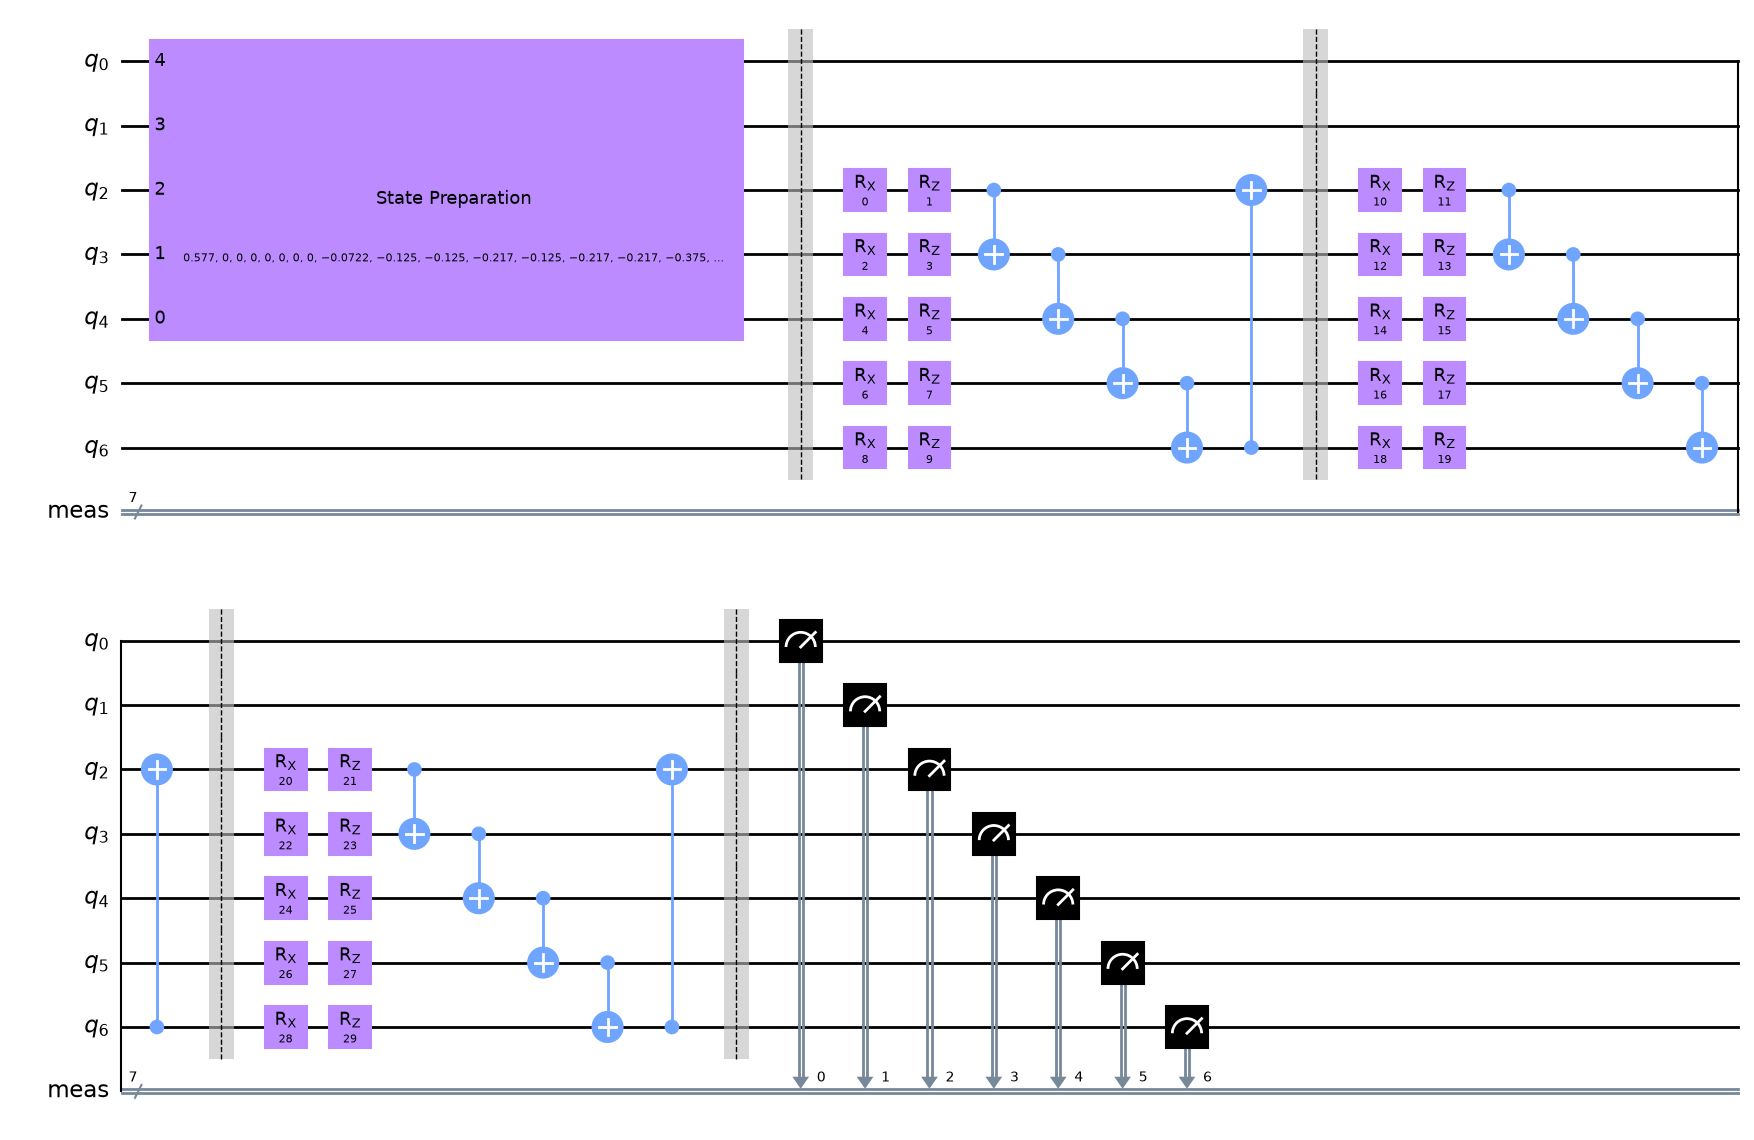

In [4]:
from numpy.random import rand
num_layers=3
num_params= 10*num_layers
params = list(range(num_params))

qc = circuit_init()
qc = PREP(qc)
Ansatz(qc, [2,3,4,5,6] , num_layers, params)

qc.draw(output='mpl', style = 'clifford') 
#qc_reversed=qc.reverse_bits()
#qc_reversed.draw(output='mpl',style = 'clifford') 

In [5]:
# ============================================================
# AWS Braket / IQM Garnet Setup
# ============================================================

from braket.aws import AwsDevice
from qiskit_braket_provider import BraketProvider
from qiskit import transpile
import numpy as np


GARNET_ARN = (
    "arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet"
)


# ============================================================
# Check IQM Garnet
# ============================================================

garnet_device = AwsDevice(
    GARNET_ARN
)


print(
    "Device name   :",
    garnet_device.name
)


print(
    "Device status :",
    garnet_device.status
)


try:

    qd = garnet_device.queue_depth()


    print(
        "Quantum-task queue :",
        qd.quantum_tasks
    )


    print(
        "Hybrid-job queue   :",
        qd.jobs
    )


except Exception as exc:

    print(
        "Queue depth unavailable:",
        exc
    )


# ============================================================
# Qiskit-Braket Backend
# ============================================================

provider = BraketProvider()


garnet_backend = provider.get_backend(
    "Garnet"
)


print(
    "Qiskit-Braket backend:",
    garnet_backend
)


# ============================================================
# Hardware Safety Switch
# ============================================================

HARDWARE_RUN = True


# ============================================================
# IQM Garnet Circuit Resource Report
# ============================================================

def circuit_resource_report(
    qc,
    backend,
    optimization_level=3,
    seed_transpiler=150
):

    tqc = transpile(
        qc,
        backend=backend,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler
    )


    op_counts = dict(
        tqc.count_ops()
    )


    one_q = 0
    two_q = 0
    multi_q = 0
    measurements = 0


    for item in tqc.data:

        name = item.operation.name

        nq = len(
            item.qubits
        )


        if name == "measure":

            measurements += 1

        elif nq == 1:

            one_q += 1

        elif nq == 2:

            two_q += 1

        elif nq > 2:

            multi_q += 1


    metrics = {

        "num_qubits":
            tqc.num_qubits,

        "depth":
            tqc.depth(),

        "size":
            tqc.size(),

        "1q_gate_count":
            one_q,

        "2q_gate_count":
            two_q,

        "multiq_gate_count":
            multi_q,

        "measurement_count":
            measurements,

        "cz_count":
            int(
                op_counts.get(
                    "cz",
                    0
                )
            ),

        "cx_count":
            int(
                op_counts.get(
                    "cx",
                    0
                )
            ),

        "operation_counts":
            op_counts,
    }


    print(
        "\n=== IQM Garnet Transpiled Resource Report ==="
    )


    for key, value in metrics.items():

        print(
            f"{key:22s}: {value}"
        )


    return tqc, metrics

Device name   : Garnet
Device status : ONLINE
Quantum-task queue : {<QueueType.NORMAL: 'Normal'>: '0', <QueueType.PRIORITY: 'Priority'>: '0'}
Hybrid-job queue   : 0
Qiskit-Braket backend: BraketBackend[Garnet]


In [6]:
# ============================================================
# Representative Circuit Resource Check
# ============================================================
# This does NOT submit a QPU task.
#
# TT QNN-CB:
#   5 QNN wires
#   10 parameters per layer
#   3 layers
#   total parameters = 30
# ============================================================

num_layers = 3

num_params = (
    10 * num_layers
)


RESOURCE_SEED = 150


resource_rng = np.random.default_rng(
    RESOURCE_SEED
)


resource_params = resource_rng.random(
    num_params
)


print(
    "\nResource-check random parameters:"
)


print(
    np.array2string(
        resource_params,
        precision=10,
        separator=", "
    )
)


qc_resource = circuit_init()


PREP(
    qc_resource
)


Ansatz(
    qc_resource,
    wires=[2, 3, 4, 5, 6],
    num_layers=num_layers,
    params=resource_params
)


qc_resource = (
    qc_resource.reverse_bits()
)


garnet_transpiled_example, garnet_resource_metrics = (
    circuit_resource_report(

        qc_resource,

        garnet_backend,

        optimization_level=3,

        seed_transpiler=RESOURCE_SEED
    )
)


Resource-check random parameters:
[0.0048220441, 0.9307870177, 0.784582211 , 0.3343249593, 0.6862689177,
 0.7322625609, 0.8246472415, 0.1074544391, 0.3089916869, 0.3129434404,
 0.5940727125, 0.6105506387, 0.9165420506, 0.7388171743, 0.3774708002,
 0.7949533184, 0.4869354822, 0.5788914075, 0.9744748566, 0.6883896757,
 0.5848087428, 0.2739643248, 0.8377858251, 0.3022293541, 0.1728462164,
 0.8017433668, 0.3441099205, 0.4375847094, 0.152681156 , 0.2761357842]

=== IQM Garnet Transpiled Resource Report ===
num_qubits            : 20
depth                 : 166
size                  : 245
1q_gate_count         : 180
2q_gate_count         : 58
multiq_gate_count     : 4
measurement_count     : 7
cz_count              : 58
cx_count              : 0
operation_counts      : {'r': 180, 'cz': 58, 'measure': 7, 'barrier': 4}


In [7]:
from scipy.optimize import minimize

import numpy as np
import os
import time


# ============================================================
# Settings
# ============================================================

num_times = 3

num_shots = 1000


optimizer_name = "COBYLA"

tol_value = 0.01

maxiter = 150


BASE_SEED = 150


num_layers = 3

num_params = (
    10 * num_layers
)


report_filename = (
    "TT_QNN_CB_IQM_Garnet_report.txt"
)


# ============================================================
# High-Shot Evaluation Settings
# ============================================================

evaluation_num_times = 5

evaluation_num_shots = 5000


EVALUATION_BASE_SEED = 10000


evaluation_seeds = np.array(
    [
        EVALUATION_BASE_SEED + i
        for i in range(
            evaluation_num_times
        )
    ],
    dtype=int
)


# ============================================================
# Storage
# ============================================================

final_optimized_values = []


initial_params_all_runs = []

optimal_params_all_runs = []


optimization_success_all_runs = []

optimization_status_all_runs = []

optimization_message_all_runs = []

optimization_nfev_all_runs = []

reached_maxiter_all_runs = []


# ------------------------------------------------------------
# Runtime Storage
# ------------------------------------------------------------

optimization_wall_times = []


# ------------------------------------------------------------
# IQM Garnet Usage Storage
# ------------------------------------------------------------

garnet_task_count = 0

garnet_total_shots = 0

garnet_task_ids = []


# ------------------------------------------------------------
# High-Shot Evaluation Storage
# ------------------------------------------------------------

evaluation_values_all_runs = []


evaluation_mean_all_runs = []

evaluation_std_all_runs = []


evaluation_min_all_runs = []

evaluation_max_all_runs = []

In [8]:
# ============================================================
# Objective Function
# ============================================================

def objective_function(
    params,
    run_seed,
    shots=None,
    print_result=True
):

    global garnet_task_count
    global garnet_total_shots
    global garnet_task_ids


    if shots is None:

        shots = num_shots


    # ========================================================
    # Construct Circuit
    # ========================================================

    qc = circuit_init()


    PREP(
        qc
    )


    Ansatz(
        qc,
        wires=[2, 3, 4, 5, 6],
        num_layers=num_layers,
        params=params
    )


    qc_reverse = (
        qc.reverse_bits()
    )


    # ========================================================
    # Transpile for IQM Garnet
    # ========================================================

    t_qc = transpile(
        qc_reverse,
        backend=garnet_backend,
        optimization_level=3,
        seed_transpiler=run_seed
    )


    # ========================================================
    # Hardware Safety Check
    # ========================================================

    if not HARDWARE_RUN:

        raise RuntimeError(
            "HARDWARE_RUN is False. "
            "QPU submission has been disabled."
        )


    # ========================================================
    # Submit to IQM Garnet
    # ========================================================

    job = garnet_backend.run(
        t_qc,
        shots=shots,
        verbatim=True
    )


    # ========================================================
    # Garnet Usage Accounting
    # ========================================================

    garnet_task_count += 1

    garnet_total_shots += int(
        shots
    )


    try:

        task_id = job.job_id()


        garnet_task_ids.append(
            task_id
        )


        if print_result:

            print(
                "Braket task ID:",
                task_id
            )


    except Exception:

        pass


    # ========================================================
    # Get Result
    # ========================================================

    result = job.result()


    counts = result.get_counts()


    # ========================================================
    # Target Counts
    # ========================================================
    #
    # TT QNN-CB is a 7-qubit circuit.
    # Keep the original [5:7] indexing.
    # ========================================================

    tar_00 = 0

    tar_01 = 0

    tar_10 = 0


    for outcome, count in counts.items():


        if outcome[0:2] == "00":

            if outcome[5:7] == "00":

                tar_00 += count


        if outcome[0:2] == "01":

            if outcome[5:7] == "01":

                tar_01 += count


        if outcome[0:2] == "10":

            if outcome[5:7] == "10":

                tar_10 += count


    # ========================================================
    # Success Probability
    # ========================================================

    p_suc = (
        tar_00
        + tar_01
        + tar_10
    ) / shots


    if print_result:

        print(
            f"success_probability = "
            f"{p_suc:.8f}"
        )


    # ========================================================
    # Avoid Division by Zero
    # ========================================================

    if p_suc == 0:

        return 1e10


    return 1.0 / p_suc

In [9]:
# ============================================================
# Objective Function
# ============================================================

def objective_function(
    params,
    run_seed,
    shots=None,
    print_result=True
):

    global garnet_task_count
    global garnet_total_shots
    global garnet_task_ids


    if shots is None:

        shots = num_shots


    # ========================================================
    # Construct Circuit
    # ========================================================

    qc = circuit_init()


    PREP(
        qc
    )


    Ansatz(
        qc,
        wires=[2, 3, 4, 5, 6],
        num_layers=num_layers,
        params=params
    )


    qc_reverse = (
        qc.reverse_bits()
    )


    # ========================================================
    # Transpile for IQM Garnet
    # ========================================================

    t_qc = transpile(
        qc_reverse,
        backend=garnet_backend,
        optimization_level=3,
        seed_transpiler=run_seed
    )


    # ========================================================
    # Hardware Safety Check
    # ========================================================

    if not HARDWARE_RUN:

        raise RuntimeError(
            "HARDWARE_RUN is False. "
            "QPU submission has been disabled."
        )


    # ========================================================
    # Submit to IQM Garnet
    # ========================================================

    job = garnet_backend.run(
        t_qc,
        shots=shots,
        verbatim=True
    )


    # ========================================================
    # Garnet Usage Accounting
    # ========================================================

    garnet_task_count += 1

    garnet_total_shots += int(
        shots
    )


    try:

        task_id = job.job_id()


        garnet_task_ids.append(
            task_id
        )


        if print_result:

            print(
                "Braket task ID:",
                task_id
            )


    except Exception:

        pass


    # ========================================================
    # Get Result
    # ========================================================

    result = job.result()


    counts = result.get_counts()


    # ========================================================
    # Target Counts
    # ========================================================
    #
    # TT QNN-CB is a 7-qubit circuit.
    # Keep the original [5:7] indexing.
    # ========================================================

    tar_00 = 0

    tar_01 = 0

    tar_10 = 0


    for outcome, count in counts.items():


        if outcome[0:2] == "00":

            if outcome[5:7] == "00":

                tar_00 += count


        if outcome[0:2] == "01":

            if outcome[5:7] == "01":

                tar_01 += count


        if outcome[0:2] == "10":

            if outcome[5:7] == "10":

                tar_10 += count


    # ========================================================
    # Success Probability
    # ========================================================

    p_suc = (
        tar_00
        + tar_01
        + tar_10
    ) / shots


    if print_result:

        print(
            f"success_probability = "
            f"{p_suc:.8f}"
        )


    # ========================================================
    # Avoid Division by Zero
    # ========================================================

    if p_suc == 0:

        return 1e10


    return 1.0 / p_suc

In [10]:
# ============================================================
# Optimization + High-Shot Evaluation + Statistics + Report
# ============================================================

total_wall_start = time.perf_counter()


# ============================================================
# Run Optimization
# ============================================================

for run in range(
    num_times
):

    run_seed = (
        BASE_SEED + run
    )


    rng = np.random.default_rng(
        run_seed
    )


    print(
        "\n"
        + "=" * 80
    )


    print(
        f"Optimization Run "
        f"{run + 1}/{num_times}"
    )


    print(
        f"Optimization Seed : "
        f"{run_seed}"
    )


    print(
        "=" * 80
    )


    # ========================================================
    # Random Initial Parameters
    # ========================================================

    initial_params = rng.random(
        num_params
    )


    initial_params_all_runs.append(
        initial_params.copy()
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params,
            precision=10,
            separator=", "
        )
    )


    # ========================================================
    # COBYLA Optimization
    # ========================================================

    optimization_start = (
        time.perf_counter()
    )


    result = minimize(

        fun=lambda params: objective_function(
            params,
            run_seed,
            shots=num_shots,
            print_result=True
        ),

        x0=initial_params,

        method=optimizer_name,

        options={
            "maxiter": maxiter,
            "disp": True,
            "tol": tol_value
        }
    )


    optimization_end = (
        time.perf_counter()
    )


    run_optimization_wall_time = (
        optimization_end
        - optimization_start
    )


    optimization_wall_times.append(
        run_optimization_wall_time
    )


    # ========================================================
    # Optimization Status
    # ========================================================

    optimization_success = bool(
        result.success
    )


    optimization_status = getattr(
        result,
        "status",
        None
    )


    optimization_message = str(
        getattr(
            result,
            "message",
            "No message returned"
        )
    )


    optimization_nfev = getattr(
        result,
        "nfev",
        None
    )


    message_lower = (
        optimization_message.lower()
    )


    reached_maxiter = (

        "maximum number"
        in message_lower

        or "maximum function"
        in message_lower

        or "maxiter"
        in message_lower

        or "maxfun"
        in message_lower

        or "maximum iterations"
        in message_lower

        or "maximum evaluations"
        in message_lower
    )


    if optimization_nfev is not None:

        if optimization_nfev >= maxiter:

            reached_maxiter = True


    optimization_success_all_runs.append(
        optimization_success
    )


    optimization_status_all_runs.append(
        optimization_status
    )


    optimization_message_all_runs.append(
        optimization_message
    )


    optimization_nfev_all_runs.append(
        optimization_nfev
    )


    reached_maxiter_all_runs.append(
        reached_maxiter
    )


    # ========================================================
    # Optimal Parameters
    # ========================================================

    optimal_params = (
        result.x.copy()
    )


    optimal_params_all_runs.append(
        optimal_params.copy()
    )


    # ========================================================
    # Final Optimization-Shot Evaluation
    # ========================================================

    final_objective = objective_function(
        optimal_params,
        run_seed,
        shots=num_shots,
        print_result=False
    )


    if final_objective >= 1e10:

        final_value = 0.0

    else:

        final_value = (
            1.0 / final_objective
        )


    final_optimized_values.append(
        final_value
    )


    # ========================================================
    # High-Shot Evaluation
    # ========================================================

    print(
        "\n"
        + "-" * 80
    )


    print(
        "HIGH-SHOT EVALUATION OF "
        "OPTIMIZED PARAMETERS"
    )


    print(
        "-" * 80
    )


    evaluation_values = []


    for eval_index, eval_seed in enumerate(
        evaluation_seeds
    ):


        eval_objective = objective_function(
            optimal_params,
            int(eval_seed),
            shots=evaluation_num_shots,
            print_result=False
        )


        if eval_objective >= 1e10:

            eval_value = 0.0

        else:

            eval_value = (
                1.0 / eval_objective
            )


        evaluation_values.append(
            eval_value
        )


        print(
            f"Evaluation "
            f"{eval_index + 1:2d}/"
            f"{evaluation_num_times:2d}"
            f" | Value = "
            f"{eval_value:.8f}"
        )


    # ========================================================
    # Evaluation Statistics
    # ========================================================

    evaluation_values = np.array(
        evaluation_values,
        dtype=float
    )


    evaluation_mean = np.mean(
        evaluation_values
    )


    evaluation_std = np.std(
        evaluation_values
    )


    evaluation_min = np.min(
        evaluation_values
    )


    evaluation_max = np.max(
        evaluation_values
    )


    evaluation_values_all_runs.append(
        evaluation_values.copy()
    )


    evaluation_mean_all_runs.append(
        evaluation_mean
    )


    evaluation_std_all_runs.append(
        evaluation_std
    )


    evaluation_min_all_runs.append(
        evaluation_min
    )


    evaluation_max_all_runs.append(
        evaluation_max
    )


    print(
        "\n"
        + "=" * 80
    )


    print(
        f"RUN {run + 1} RESULT"
    )


    print(
        "=" * 80
    )


    print(
        f"Optimization Success : "
        f"{optimization_success}"
    )


    print(
        f"Reached MaxIter      : "
        f"{reached_maxiter}"
    )


    print(
        f"Status               : "
        f"{optimization_status}"
    )


    print(
        f"Message              : "
        f"{optimization_message}"
    )


    print(
        f"Function Evaluations : "
        f"{optimization_nfev}"
    )


    print(
        f"Optimization Time    : "
        f"{run_optimization_wall_time:.6f} s"
    )


    print(
        f"Final Optimized Value: "
        f"{final_value:.8f}"
    )


    print(
        f"Evaluated Mean       : "
        f"{evaluation_mean:.8f}"
    )


    print(
        f"Evaluated Std        : "
        f"{evaluation_std:.8f}"
    )


    print(
        f"Evaluated Min        : "
        f"{evaluation_min:.8f}"
    )


    print(
        f"Evaluated Max        : "
        f"{evaluation_max:.8f}"
    )


    print(
        "\nEvaluated Values:"
    )


    print(
        np.array2string(
            evaluation_values,
            precision=8,
            separator=", "
        )
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params,
            precision=10,
            separator=", "
        )
    )


    print(
        "\nOptimal Parameters:"
    )


    print(
        np.array2string(
            optimal_params,
            precision=10,
            separator=", "
        )
    )


# ============================================================
# Runtime Statistics
# ============================================================

total_wall_end = (
    time.perf_counter()
)


total_wall_time = (
    total_wall_end
    - total_wall_start
)


optimization_wall_times = np.array(
    optimization_wall_times,
    dtype=float
)


total_optimization_wall_time = np.sum(
    optimization_wall_times
)


mean_optimization_wall_time = np.mean(
    optimization_wall_times
)


std_optimization_wall_time = np.std(
    optimization_wall_times
)


# ============================================================
# Convert Arrays
# ============================================================

final_optimized_values = np.array(
    final_optimized_values,
    dtype=float
)


initial_params_all_runs = np.array(
    initial_params_all_runs
)


optimal_params_all_runs = np.array(
    optimal_params_all_runs
)


evaluation_values_all_runs = np.array(
    evaluation_values_all_runs,
    dtype=float
)


evaluation_mean_all_runs = np.array(
    evaluation_mean_all_runs,
    dtype=float
)


evaluation_std_all_runs = np.array(
    evaluation_std_all_runs,
    dtype=float
)


evaluation_min_all_runs = np.array(
    evaluation_min_all_runs,
    dtype=float
)


evaluation_max_all_runs = np.array(
    evaluation_max_all_runs,
    dtype=float
)


# ============================================================
# Statistics
# ============================================================

maximum_value = np.max(
    final_optimized_values
)


mean_value = np.mean(
    final_optimized_values
)


std_value = np.std(
    final_optimized_values
)


maximum_run_index = np.argmax(
    final_optimized_values
)


maximum_run = (
    maximum_run_index + 1
)


maximum_evaluated_mean = np.max(
    evaluation_mean_all_runs
)


maximum_evaluated_mean_run_index = np.argmax(
    evaluation_mean_all_runs
)


maximum_evaluated_mean_run = (
    maximum_evaluated_mean_run_index
    + 1
)


mean_of_evaluated_means = np.mean(
    evaluation_mean_all_runs
)


std_of_evaluated_means = np.std(
    evaluation_mean_all_runs
)


nfev_values = np.array(
    [
        nfev
        for nfev in optimization_nfev_all_runs
        if nfev is not None
    ],
    dtype=float
)


if len(
    nfev_values
) > 0:

    mean_nfev = np.mean(
        nfev_values
    )

    std_nfev = np.std(
        nfev_values
    )

else:

    mean_nfev = np.nan

    std_nfev = np.nan


num_successful_runs = sum(
    optimization_success_all_runs
)


num_failed_runs = (
    num_times
    - num_successful_runs
)


num_reached_maxiter = sum(
    reached_maxiter_all_runs
)


best_initial_params = (
    initial_params_all_runs[
        maximum_run_index
    ]
)


best_optimal_params = (
    optimal_params_all_runs[
        maximum_run_index
    ]
)


best_evaluated_initial_params = (
    initial_params_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


best_evaluated_optimal_params = (
    optimal_params_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


best_evaluated_values = (
    evaluation_values_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


# ============================================================
# Print Final Report
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "FINAL OPTIMIZATION AND HIGH-SHOT EVALUATION REPORT"
)


print(
    "=" * 100
)


print(
    f"Hardware                : IQM Garnet"
)


print(
    f"Hardware ARN            : {GARNET_ARN}"
)


print(
    f"Ansatz                  : TT QNN-CB"
)


print(
    f"Optimizer               : {optimizer_name}"
)


print(
    f"Tolerance               : {tol_value}"
)


print(
    f"Max Iteration           : {maxiter}"
)


print(
    f"Number of Runs          : {num_times}"
)


print(
    f"Number of Layers        : {num_layers}"
)


print(
    f"Number of Parameters    : {num_params}"
)


print(
    f"Optimization Shots      : {num_shots}"
)


print(
    f"Optimization Base Seed  : {BASE_SEED}"
)


print(
    f"Evaluation Shots        : {evaluation_num_shots}"
)


print(
    f"Evaluations Per Run     : {evaluation_num_times}"
)


print(
    f"Evaluation Base Seed    : {EVALUATION_BASE_SEED}"
)


print(
    "Evaluation Seeds        : "
    + np.array2string(
        evaluation_seeds,
        separator=", "
    )
)


print(
    f"Resource Parameter Seed : {RESOURCE_SEED}"
)


print(
    "=" * 100
)


# ============================================================
# Results for Each Run
# ============================================================

for i in range(
    num_times
):

    print(
        f"\nRun {i + 1:2d}"
    )


    print(
        "-" * 100
    )


    print(
        f"Optimization Seed : {BASE_SEED + i}"
    )


    print(
        f"Optimized Value   : "
        f"{final_optimized_values[i]:.8f}"
    )


    print(
        f"Evaluated Mean    : "
        f"{evaluation_mean_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Std     : "
        f"{evaluation_std_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Min     : "
        f"{evaluation_min_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Max     : "
        f"{evaluation_max_all_runs[i]:.8f}"
    )


    print(
        f"Success           : "
        f"{optimization_success_all_runs[i]}"
    )


    print(
        f"Reached MaxIter   : "
        f"{reached_maxiter_all_runs[i]}"
    )


    print(
        f"Status            : "
        f"{optimization_status_all_runs[i]}"
    )


    print(
        f"Message           : "
        f"{optimization_message_all_runs[i]}"
    )


    print(
        f"Function Evals    : "
        f"{optimization_nfev_all_runs[i]}"
    )


    print(
        f"Optimization Time : "
        f"{optimization_wall_times[i]:.6f} s"
    )


    print(
        "\nEvaluated Values:"
    )


    print(
        np.array2string(
            evaluation_values_all_runs[i],
            precision=8,
            separator=", "
        )
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params_all_runs[i],
            precision=10,
            separator=", "
        )
    )


    print(
        "\nOptimal Parameters:"
    )


    print(
        np.array2string(
            optimal_params_all_runs[i],
            precision=10,
            separator=", "
        )
    )


# ============================================================
# Summary
# ============================================================

print(
    "\nSUMMARY"
)


print(
    "=" * 100
)


print(
    "\nOriginal Optimization-Shot Results:"
)


print(
    f"Maximum Optimized Value : "
    f"{maximum_value:.8f}"
)


print(
    f"Maximum Run             : "
    f"{maximum_run}"
)


print(
    f"Mean Optimized Value    : "
    f"{mean_value:.8f}"
)


print(
    f"Std Optimized Value     : "
    f"{std_value:.8f}"
)


print(
    "\nHigh-Shot Evaluation Results:"
)


print(
    f"Best Evaluated Mean     : "
    f"{maximum_evaluated_mean:.8f}"
)


print(
    f"Best Evaluated Mean Run : "
    f"{maximum_evaluated_mean_run}"
)


print(
    f"Mean of Evaluated Means : "
    f"{mean_of_evaluated_means:.8f}"
)


print(
    f"Std of Evaluated Means  : "
    f"{std_of_evaluated_means:.8f}"
)


print(
    "\nOptimizer Statistics:"
)


print(
    f"Mean Function Evals     : "
    f"{mean_nfev:.2f}"
)


print(
    f"Std Function Evals      : "
    f"{std_nfev:.2f}"
)


print(
    f"Successful Runs         : "
    f"{num_successful_runs}/{num_times}"
)


print(
    f"Failed Runs             : "
    f"{num_failed_runs}/{num_times}"
)


print(
    f"Reached MaxIter         : "
    f"{num_reached_maxiter}/{num_times}"
)


print(
    "\nComputational Runtime Statistics:"
)


print(
    f"Total Wall-Clock Time          : "
    f"{total_wall_time:.6f} s"
)


print(
    f"Total Optimization Time        : "
    f"{total_optimization_wall_time:.6f} s"
)


print(
    f"Time per Complete Opt. Run     : "
    f"{mean_optimization_wall_time:.6f} s"
)


print(
    f"Std Optimization Time per Run  : "
    f"{std_optimization_wall_time:.6f} s"
)


# ============================================================
# Best Run According to Original Value
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "BEST RUN ACCORDING TO ORIGINAL OPTIMIZED VALUE"
)


print(
    "=" * 100
)


print(
    f"Run             : {maximum_run}"
)


print(
    f"Optimized Value : "
    f"{final_optimized_values[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Mean  : "
    f"{evaluation_mean_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Std   : "
    f"{evaluation_std_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Min   : "
    f"{evaluation_min_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Max   : "
    f"{evaluation_max_all_runs[maximum_run_index]:.8f}"
)


print(
    "\nEvaluated Values:"
)


print(
    np.array2string(
        evaluation_values_all_runs[
            maximum_run_index
        ],
        precision=8,
        separator=", "
    )
)


print(
    "\nInitial Parameters:"
)


print(
    np.array2string(
        best_initial_params,
        precision=10,
        separator=", "
    )
)


print(
    "\nOptimal Parameters:"
)


print(
    np.array2string(
        best_optimal_params,
        precision=10,
        separator=", "
    )
)


# ============================================================
# Best Run According to High-Shot Evaluated Mean
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "BEST RUN ACCORDING TO HIGH-SHOT EVALUATED MEAN"
)


print(
    "=" * 100
)


print(
    f"Run             : "
    f"{maximum_evaluated_mean_run}"
)


print(
    f"Optimized Value : "
    f"{final_optimized_values[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Mean  : "
    f"{evaluation_mean_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Std   : "
    f"{evaluation_std_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Min   : "
    f"{evaluation_min_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Max   : "
    f"{evaluation_max_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    "\nEvaluated Values:"
)


print(
    np.array2string(
        best_evaluated_values,
        precision=8,
        separator=", "
    )
)


print(
    "\nInitial Parameters:"
)


print(
    np.array2string(
        best_evaluated_initial_params,
        precision=10,
        separator=", "
    )
)


print(
    "\nOptimal Parameters:"
)


print(
    np.array2string(
        best_evaluated_optimal_params,
        precision=10,
        separator=", "
    )
)


# ============================================================
# IQM Garnet QPU Usage Summary
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "IQM GARNET QPU USAGE SUMMARY"
)


print(
    "=" * 100
)


print(
    f"Total QPU Tasks Submitted : "
    f"{garnet_task_count}"
)


print(
    f"Total QPU Shots Submitted : "
    f"{garnet_total_shots}"
)


print(
    "\nBraket Task IDs:"
)


for i, task_id in enumerate(
    garnet_task_ids,
    start=1
):

    print(
        f"{i:4d}: {task_id}"
    )


print(
    "\nRepresentative Transpiled Circuit Resources:"
)


for key, value in garnet_resource_metrics.items():

    print(
        f"{key:22s}: {value}"
    )


# ============================================================
# Save Report
# ============================================================

with open(
    report_filename,
    "w"
) as f:

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "FINAL OPTIMIZATION AND "
        "HIGH-SHOT EVALUATION REPORT\n"
    )


    f.write(
        "=" * 100
        + "\n\n"
    )


    f.write(
        f"Hardware                : IQM Garnet\n"
    )


    f.write(
        f"Hardware ARN            : {GARNET_ARN}\n"
    )


    f.write(
        f"Ansatz                  : TT QNN-CB\n"
    )


    f.write(
        f"Optimizer               : {optimizer_name}\n"
    )


    f.write(
        f"Tolerance               : {tol_value}\n"
    )


    f.write(
        f"Max Iteration           : {maxiter}\n"
    )


    f.write(
        f"Number of Runs          : {num_times}\n"
    )


    f.write(
        f"Number of Layers        : {num_layers}\n"
    )


    f.write(
        f"Number of Parameters    : {num_params}\n"
    )


    f.write(
        f"Optimization Shots      : {num_shots}\n"
    )


    f.write(
        f"Optimization Base Seed  : {BASE_SEED}\n"
    )


    f.write(
        f"Evaluation Shots        : {evaluation_num_shots}\n"
    )


    f.write(
        f"Evaluations Per Run     : {evaluation_num_times}\n"
    )


    f.write(
        f"Evaluation Base Seed    : {EVALUATION_BASE_SEED}\n"
    )


    f.write(
        "Evaluation Seeds        : "
        + np.array2string(
            evaluation_seeds,
            separator=", "
        )
        + "\n"
    )


    f.write(
        f"Resource Parameter Seed : {RESOURCE_SEED}\n\n"
    )


    # ========================================================
    # Results for Every Run
    # ========================================================

    for i in range(
        num_times
    ):

        f.write(
            "\n"
            + "=" * 100
            + "\n"
        )


        f.write(
            f"RUN {i + 1}\n"
        )


        f.write(
            "=" * 100
            + "\n"
        )


        f.write(
            f"Optimization Seed : {BASE_SEED + i}\n"
        )


        f.write(
            f"Optimized Value   : "
            f"{final_optimized_values[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Mean    : "
            f"{evaluation_mean_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Std     : "
            f"{evaluation_std_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Min     : "
            f"{evaluation_min_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Max     : "
            f"{evaluation_max_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Success           : "
            f"{optimization_success_all_runs[i]}\n"
        )


        f.write(
            f"Reached MaxIter   : "
            f"{reached_maxiter_all_runs[i]}\n"
        )


        f.write(
            f"Status            : "
            f"{optimization_status_all_runs[i]}\n"
        )


        f.write(
            f"Message           : "
            f"{optimization_message_all_runs[i]}\n"
        )


        f.write(
            f"Function Evals    : "
            f"{optimization_nfev_all_runs[i]}\n"
        )


        f.write(
            f"Optimization Time : "
            f"{optimization_wall_times[i]:.6f} s\n"
        )


        f.write(
            "\nEvaluated Values:\n"
        )


        f.write(
            np.array2string(
                evaluation_values_all_runs[i],
                precision=8,
                separator=", "
            )
            + "\n"
        )


        f.write(
            "\nInitial Parameters:\n"
        )


        f.write(
            np.array2string(
                initial_params_all_runs[i],
                precision=10,
                separator=", "
            )
            + "\n"
        )


        f.write(
            "\nOptimal Parameters:\n"
        )


        f.write(
            np.array2string(
                optimal_params_all_runs[i],
                precision=10,
                separator=", "
            )
            + "\n"
        )


    # ========================================================
    # Summary
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )


    f.write(
        "SUMMARY\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "\nOriginal Optimization-Shot Results:\n"
    )


    f.write(
        f"Maximum Optimized Value : "
        f"{maximum_value:.8f}\n"
    )


    f.write(
        f"Maximum Run             : {maximum_run}\n"
    )


    f.write(
        f"Mean Optimized Value    : "
        f"{mean_value:.8f}\n"
    )


    f.write(
        f"Std Optimized Value     : "
        f"{std_value:.8f}\n"
    )


    f.write(
        "\nHigh-Shot Evaluation Results:\n"
    )


    f.write(
        f"Best Evaluated Mean     : "
        f"{maximum_evaluated_mean:.8f}\n"
    )


    f.write(
        f"Best Evaluated Mean Run : "
        f"{maximum_evaluated_mean_run}\n"
    )


    f.write(
        f"Mean of Evaluated Means : "
        f"{mean_of_evaluated_means:.8f}\n"
    )


    f.write(
        f"Std of Evaluated Means  : "
        f"{std_of_evaluated_means:.8f}\n"
    )


    f.write(
        "\nOptimizer Statistics:\n"
    )


    f.write(
        f"Mean Function Evals     : "
        f"{mean_nfev:.2f}\n"
    )


    f.write(
        f"Std Function Evals      : "
        f"{std_nfev:.2f}\n"
    )


    f.write(
        f"Successful Runs         : "
        f"{num_successful_runs}/{num_times}\n"
    )


    f.write(
        f"Failed Runs             : "
        f"{num_failed_runs}/{num_times}\n"
    )


    f.write(
        f"Reached MaxIter         : "
        f"{num_reached_maxiter}/{num_times}\n"
    )


    f.write(
        "\nComputational Runtime Statistics:\n"
    )


    f.write(
        f"Total Wall-Clock Time          : "
        f"{total_wall_time:.6f} s\n"
    )


    f.write(
        f"Total Optimization Time        : "
        f"{total_optimization_wall_time:.6f} s\n"
    )


    f.write(
        f"Time per Complete Opt. Run     : "
        f"{mean_optimization_wall_time:.6f} s\n"
    )


    f.write(
        f"Std Optimization Time per Run  : "
        f"{std_optimization_wall_time:.6f} s\n"
    )


    # ========================================================
    # Best Run by Original Optimized Value
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )


    f.write(
        "BEST RUN ACCORDING TO ORIGINAL OPTIMIZED VALUE\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Run             : {maximum_run}\n"
    )


    f.write(
        f"Optimized Value : "
        f"{final_optimized_values[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Mean  : "
        f"{evaluation_mean_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Std   : "
        f"{evaluation_std_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Min   : "
        f"{evaluation_min_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Max   : "
        f"{evaluation_max_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        "\nEvaluated Values:\n"
    )


    f.write(
        np.array2string(
            evaluation_values_all_runs[
                maximum_run_index
            ],
            precision=8,
            separator=", "
        )
        + "\n"
    )


    f.write(
        "\nInitial Parameters:\n"
    )


    f.write(
        np.array2string(
            best_initial_params,
            precision=10,
            separator=", "
        )
        + "\n"
    )


    f.write(
        "\nOptimal Parameters:\n"
    )


    f.write(
        np.array2string(
            best_optimal_params,
            precision=10,
            separator=", "
        )
        + "\n"
    )


    # ========================================================
    # Best Run by High-Shot Mean
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )


    f.write(
        "BEST RUN ACCORDING TO HIGH-SHOT EVALUATED MEAN\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Run             : "
        f"{maximum_evaluated_mean_run}\n"
    )


    f.write(
        f"Optimized Value : "
        f"{final_optimized_values[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Mean  : "
        f"{evaluation_mean_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Std   : "
        f"{evaluation_std_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Min   : "
        f"{evaluation_min_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Max   : "
        f"{evaluation_max_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        "\nEvaluated Values:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_values,
            precision=8,
            separator=", "
        )
        + "\n"
    )


    f.write(
        "\nInitial Parameters:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_initial_params,
            precision=10,
            separator=", "
        )
        + "\n"
    )


    f.write(
        "\nOptimal Parameters:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_optimal_params,
            precision=10,
            separator=", "
        )
        + "\n"
    )


    # ========================================================
    # Garnet Usage Summary
    # ========================================================

    f.write(
        "\n"
        + "=" * 100
        + "\n"
    )


    f.write(
        "IQM GARNET QPU USAGE SUMMARY\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Total QPU Tasks Submitted : "
        f"{garnet_task_count}\n"
    )


    f.write(
        f"Total QPU Shots Submitted : "
        f"{garnet_total_shots}\n"
    )


    f.write(
        "\nBraket Task IDs:\n"
    )


    for i, task_id in enumerate(
        garnet_task_ids,
        start=1
    ):

        f.write(
            f"{i:4d}: {task_id}\n"
        )


    f.write(
        "\nRepresentative Transpiled Circuit Resources:\n"
    )


    for key, value in garnet_resource_metrics.items():

        f.write(
            f"{key:22s}: {value}\n"
        )


print(
    "\nReport saved to:"
)


print(
    os.path.abspath(
        report_filename
    )
)


Optimization Run 1/3
Optimization Seed : 150

Initial Parameters:
[0.0048220441, 0.9307870177, 0.784582211 , 0.3343249593, 0.6862689177,
 0.7322625609, 0.8246472415, 0.1074544391, 0.3089916869, 0.3129434404,
 0.5940727125, 0.6105506387, 0.9165420506, 0.7388171743, 0.3774708002,
 0.7949533184, 0.4869354822, 0.5788914075, 0.9744748566, 0.6883896757,
 0.5848087428, 0.2739643248, 0.8377858251, 0.3022293541, 0.1728462164,
 0.8017433668, 0.3441099205, 0.4375847094, 0.152681156 , 0.2761357842]


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(
/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 3.926990816987252 will not be included in Braket circuit
  _translate_to_braket(


Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/8869f9a1-1514-44be-84a6-2ccd1badcee9
success_probability = 0.24300000


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 0.7853981633974572 will not be included in Braket circuit
  _translate_to_braket(


Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/be741175-a8fd-4c77-86ad-a0d8f2bf130d
success_probability = 0.23100000


...

Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/dd032d44-7193-46e1-9fe1-5b0b585b9103
success_probability = 0.25300000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/d6c8b0a2-7be0-4773-bd28-9498b77b5464
success_probability = 0.26200000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/332bf435-77e1-4e37-ab01-d94f0ac1b370
success_probability = 0.26700000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/d39e05a4-6b2c-4b1d-8342-4eab3bb7055a
success_probability = 0.24200000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/09e03d30-38f8-468b-802a-4feee2476246
success_probability = 0.24600000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/41b193b8-d6b8-4ae6-83f4-e55f667f855b
success_probability = 0.24300000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/4839e06a-9fbb-438b-a3dd-e8d86f4dbf4a
success_probability = 0.25600000
Braket task ID: arn:aws:braket:eu-

/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 3.9269908169872534 will not be included in Braket circuit
  _translate_to_braket(


Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/578875ae-845f-4c80-a88b-a372d772ea72
success_probability = 0.24800000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/f3a8e859-d74f-4b5c-937a-8498419c1da3
success_probability = 0.22900000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/8cbd5ff1-234a-4fc6-8afa-a67c60447016
success_probability = 0.22600000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/1c48dffe-f51c-4607-a401-a5f444f46a18
success_probability = 0.26700000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/20f75b9b-cc88-42b9-bfdb-317c77bb8f0c
success_probability = 0.23300000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/98f73316-8510-4f6e-86d2-0588025bba6a
success_probability = 0.26900000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/9eb330e0-68c7-49f5-94ef-6dc03694fb6e
success_probability = 0.24700000
Braket task ID: arn:aws:braket:eu-

/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 3.9269908169872476 will not be included in Braket circuit
  _translate_to_braket(


Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/5d474a9e-1e3d-4f12-a21b-c880dcec7960
success_probability = 0.23900000
Braket task ID: arn:aws:braket:eu-north-1:082674088760:quantum-task/106191dd-62aa-4f3c-be64-5d86bf327e0b
success_probability = 0.22900000

   Normal return from subroutine COBYLA

   NFVALS =  136   F = 4.366812E+00    MAXCV = 0.000000E+00
   X = 1.224990E+00   2.615667E-01   4.934436E-02   1.540226E+00   5.376818E-01
       7.888427E-01   9.124187E-01   3.721358E-01   1.325708E+00   6.557950E-01
       9.007239E-01   6.518818E-01   7.816901E-01   1.874493E+00   1.922044E-01
       6.130251E-01   9.467742E-01   8.216577E-01   1.223888E+00   1.545951E+00
       8.715795E-01   1.801162E+00   3.459309E-02   9.286685E-02   7.622975E-01
       7.680647E-01   1.193061E-01   1.129404E-01   4.884156E-01   3.766544E-01

--------------------------------------------------------------------------------
HIGH-SHOT EVALUATION OF OPTIMIZED PARAMETERS
---------------